step 1:import required libraries

In [1]:
import pandas as pd
import numpy as np
import re # data cleaning
import nltk
import matplotlib.pyplot as plt
from nltk.corpus import stopwords # to remove the unnecessary words
from nltk.tokenize import word_tokenize
from nltk.sentiment import SentimentIntensityAnalyzer
from collections import Counter
from wordcloud import WordCloud # to visualize the words

In [2]:
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('vader_lexicon')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [3]:
data = {
    "Review" : [
        "The product quality is excellent and delivery was very fast.",
        "Very bad packaging and the item was damaged.",
        "Customer service was helpful and responsive.",
        "The delivery was delayed and support team did not respond.",
        "Amazing product.Worth the money.",
        "Poor quality product and terrible experience.",
        "Fast shipping and good packaging.",
        "The product stopped working after two days.",
        "Excellent service and great quality.",
        "Late delivery and bad customer support."
    ]
}

In [5]:
df=pd.DataFrame(data)
df.head()

,Review
0,The product quality is excellent and delivery ...
1,Very bad packaging and the item was damaged.
2,Customer service was helpful and responsive.
3,The delivery was delayed and support team did ...
4,Amazing product.Worth the money.


In [28]:
stop_words=set(stopwords.words('english'))
def clean_text(text):
    text=text.lower()#convert to lower case
    text=re.sub(r'[^a-z\s]','',text) # remove special characters, keeping only letters and spaces
    #tokenization
    words=word_tokenize(text)
    #remove stop words
    words=[word for word in words if word not in stop_words]
    #join words again
    cleaned_text=' '.join(words)
    return cleaned_text
df["cleaned_review"]=df['Review'].apply(clean_text)
print(df)

                                              Review  \
0  The product quality is excellent and delivery ...   
1       Very bad packaging and the item was damaged.   
2       Customer service was helpful and responsive.   
3  The delivery was delayed and support team did ...   
4                   Amazing product.Worth the money.   
5      Poor quality product and terrible experience.   
6                  Fast shipping and good packaging.   
7        The product stopped working after two days.   
8               Excellent service and great quality.   
9            Late delivery and bad customer support.   

                             cleaned_review sentimate  
0   product quality excellent delivery fast   neutral  
1                bad packaging item damaged   neutral  
2       customer service helpful responsive   neutral  
3     delivery delayed support team respond   neutral  
4                amazing productworth money   neutral  
5  poor quality product terrible experience   n

In [29]:
#sentimate analysis

nlp=SentimentIntensityAnalyzer()
def sentimate_analysis(Review):
    score=nlp.polarity_scores(Review)
    compound=score['compound']
    if compound>0:
        return 'positive'
    elif compound<0:
        return 'negative'
    else:
        return 'neutral'
df['sentimate']=df['cleaned_review'].apply(sentimate_analysis)
print(df[['Review','cleaned_review', 'sentimate']])

                                              Review  \
0  The product quality is excellent and delivery ...   
1       Very bad packaging and the item was damaged.   
2       Customer service was helpful and responsive.   
3  The delivery was delayed and support team did ...   
4                   Amazing product.Worth the money.   
5      Poor quality product and terrible experience.   
6                  Fast shipping and good packaging.   
7        The product stopped working after two days.   
8               Excellent service and great quality.   
9            Late delivery and bad customer support.   

                             cleaned_review sentimate  
0   product quality excellent delivery fast  positive  
1                bad packaging item damaged  negative  
2       customer service helpful responsive  positive  
3     delivery delayed support team respond  positive  
4                amazing productworth money  positive  
5  poor quality product terrible experience  ne

In [30]:
#find common keyword
nlp_words=' '.join(df['cleaned_review'])
word_list=nlp_words.split()
word_freq=Counter(word_list)
print("Common Keyword")
common_words=word_freq.most_common(5)
print(word_freq.most_common(5))

Common Keyword
[('product', 3), ('quality', 3), ('delivery', 3), ('excellent', 2), ('fast', 2)]


In [31]:
#identify common complients
negative_review=df[df['sentimate']=='negative']
negative_words=' '.join(negative_review['cleaned_review'])
negative_word_list=negative_words.split()
complaint_freq=Counter(negative_word_list)
print("common complaints")
print(complaint_freq.most_common(5))

common complaints
[('bad', 2), ('product', 2), ('packaging', 1), ('item', 1), ('damaged', 1)]


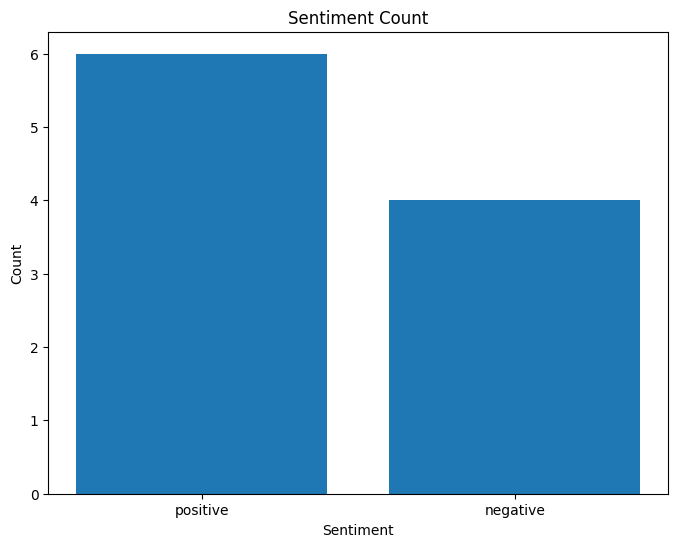

In [32]:
#visualization-sentiment count
sentiment_counts=df['sentimate'].value_counts()
plt.figure(figsize=(8,6))
plt.bar(sentiment_counts.index,sentiment_counts.values)
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.title('Sentiment Count')
plt.show()

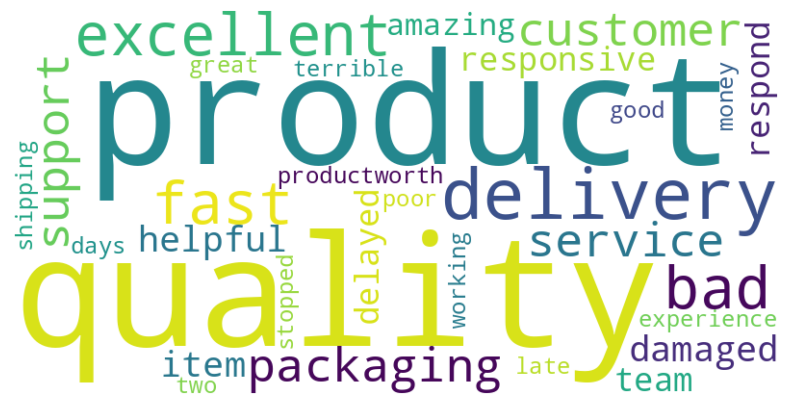

In [36]:
#genrate word cloud
word_cloud=WordCloud(
    width=800,
    height=400,
    background_color='white'
)
word_cloud.generate(nlp_words)
plt.figure(figsize=(10,5))
plt.imshow(word_cloud,interpolation='bilinear')
plt.axis('off')
plt.show()